## **Machine Learning Aplicado a las Finanzas** 🚀
### **Sesión 6: Clustering — Regímenes y Segmentación de Activos**

Andrés C. Medina Sanhueza  
Senior Data Scientist Engineer  
anmedinas@gmail.com

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform, pdist
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
import seaborn as sns
import yfinance as yf

sns.set_style('dark')
warnings.filterwarnings('ignore')
np.random.seed(42)

## 🍁 **`Motivación`**

### El problema de la heterogeneidad en mercados financieros

<tr>
<td><img src="../figs/figura_015.png" align="middle" style="width: 1000px;"/> </td>
</tr>

Un universo de $n$ activos no es un conjunto homogéneo: las acciones tecnológicas se mueven con el ciclo de innovación, las utilities con las tasas de interés, los commodities con el ciclo económico global. Ignorar esta estructura heterogénea lleva a:

1. **Portafolios mal diversificados**: dos activos con correlación 0.95 contribuyen casi lo mismo al riesgo, pero cuentan como dos posiciones distintas.
   
2. **Modelos de riesgo inestables**: estimar $\frac{n(n+1)}{2}$ parámetros de covarianza sin estructura previa produce matrices singulares.

3. **Señales de trading ruidosas**: mezclar activos de distintos regímenes en el mismo modelo produce promedios sin significado económico.



### Clustering como solución

El **clustering** busca particiones $\mathcal{C} = \{C_1, \dots, C_k\}$ del universo de activos tal que:

$$\text{similitud}(x_i, x_j) \text{ alta si } x_i, x_j \in C_k \qquad \text{y baja si } x_i \in C_k,\, x_j \in C_l,\; k \neq l$$

En finanzas tiene dos grandes aplicaciones:

| Aplicación | Descripción | Dimensión del clustering |
|---|---|---|
| **Segmentación de activos** | Agrupar activos por comportamiento similar | Sobre el espacio de activos ($n$ objetos) |
| **Detección de regímenes** | Identificar estados del mercado en el tiempo | Sobre el espacio temporal ($T$ observaciones) |

### El concepto de régimen de mercado

Un **régimen** es un estado latente que gobierna la dinámica del mercado durante un período:

| Régimen | Retorno esperado | Volatilidad | Correlaciones |
|---|---|---|---|
| Bull / Expansión | Alto y positivo | Baja | Moderadas |
| Bear / Contracción | Negativo | Alta | Altas ("all corr → 1") |
| Crisis / Tail event | Muy negativo | Muy alta | Cercanas a 1 |
| Lateral / Transición | Cercano a 0 | Media | Variables |

### ¿Por qué existe la heterogeneidad? Los ciclos económicos como driver estructural

La heterogeneidad en los mercados no es ruido aleatorio — tiene **estructura económica profunda**. Cada sector está dominado por un tipo de ciclo distinto, lo que determina cuándo sube, cuándo cae y con qué otros activos se mueve:

| Ciclo | Duración típica | Sectores más expuestos | Mecanismo económico |
|---|---|---|---|
| **Kitchin** (inventarios) | 3–5 años | Consumo Discrecional, Industriales | Acumulación y liquidación de inventarios empresariales |
| **Juglar** (inversión) | 7–11 años | Financiero, Industriales | Ciclos de crédito e inversión en capital fijo |
| **Kuznets** (construcción) | 15–25 años | Real Estate, Materiales | Ciclos demográficos e infraestructura |
| **Kondratiev** (innovación) | 40–60 años | Tecnología, Comunicaciones | Adopción masiva de nuevas tecnologías (vapor → electricidad → TICs → IA) |
| **Ciclo de tasas** | Variable | Utilities, Real Estate | Decisiones de política monetaria del banco central |
| **Superciclo commodities** | 15–20 años | Energía, Materiales | Ciclos de oferta/demanda global de materias primas |

Esto tiene una consecuencia directa sobre las **correlaciones**: en una expansión económica, cada sector sigue su propio driver y las correlaciones entre ellos son moderadas. En una crisis severa, el factor de liquidez domina y todas las correlaciones convergen a 1 — el famoso *"all correlations go to 1 in a crisis"*. La estructura de dependencia **no es estacionaria**.

#### La falacia ecológica en finanzas

Si ignoramos esta estructura y ajustamos un único modelo sobre todo el universo de activos, cometemos la **falacia ecológica**: usamos un parámetro promediado sobre grupos heterogéneos que no representa bien a ninguno de ellos.

**Ejemplo:** imagina estimar el beta de mercado de un universo con partes iguales de Tech ($\beta \approx 1.4$) y Utilities ($\beta \approx 0.5$). La beta global resultante ($\beta \approx 0.95$) no describe el comportamiento de ninguno de los dos sectores — es un promedio que produce predicciones malas para ambos.

> La siguiente simulacion demuestra cuantitativamente este problema y muestra por qué separar los activos en grupos homogéneos mejora radicalmente el poder explicativo de los modelos.

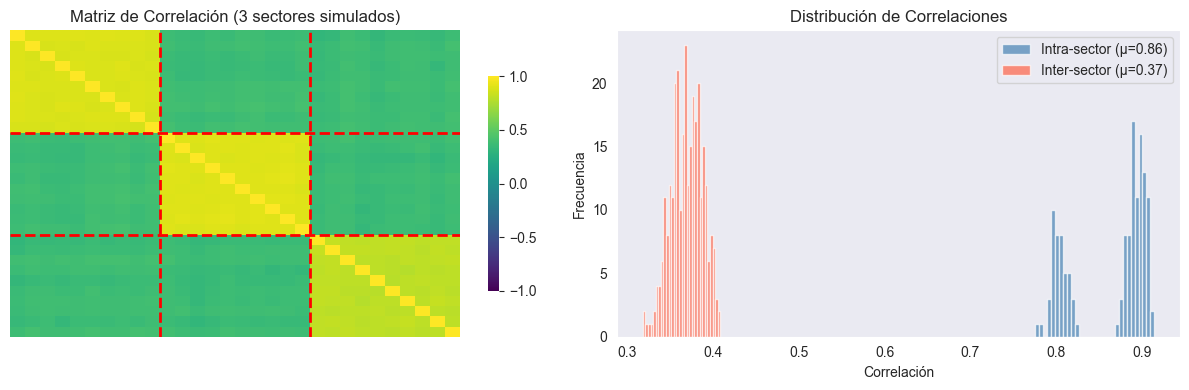

In [2]:
# Simulación: 3 grupos de activos con distintos perfiles de riesgo
n_per_group = 10
T = 500

market  = np.random.randn(T) * 0.01
sector1 = np.random.randn(T) * 0.015   # Tech: alta vol
sector2 = np.random.randn(T) * 0.006   # Utilities: defensivo
sector3 = np.random.randn(T) * 0.012   # Financiero

R = np.zeros((T, 3 * n_per_group))
for i in range(n_per_group):
    R[:, i]                = 0.8*market + 0.6*sector1 + np.random.randn(T)*0.004
for i in range(n_per_group):
    R[:, n_per_group+i]    = 0.4*market + 0.8*sector2 + np.random.randn(T)*0.002
for i in range(n_per_group):
    R[:, 2*n_per_group+i]  = 0.7*market + 0.6*sector3 + np.random.randn(T)*0.005

corr    = pd.DataFrame(R).corr().values
n_total = 3 * n_per_group

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(corr, ax=axes[0], cmap='viridis', vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.7})
for cut in [10, 20]:
    axes[0].axvline(cut, color='red', lw=2, ls='--')
    axes[0].axhline(cut, color='red', lw=2, ls='--')
axes[0].set_title('Matriz de Correlación (3 sectores simulados)')

intra, inter = [], []
for i in range(n_total):
    for j in range(i+1, n_total):
        (intra if i//n_per_group == j//n_per_group else inter).append(corr[i, j])

axes[1].hist(intra, bins=30, alpha=0.7, color='steelblue',
             label=f'Intra-sector (μ={np.mean(intra):.2f})')
axes[1].hist(inter, bins=30, alpha=0.7, color='tomato',
             label=f'Inter-sector (μ={np.mean(inter):.2f})')
axes[1].set_xlabel('Correlación')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Correlaciones')
axes[1].legend()

plt.tight_layout()
plt.show()

**Matriz de Correlación (izquierda):** las líneas rojas delimitan los 3 sectores simulados. Dentro de cada bloque diagonal (intra-sector) predominan colores cálidos (correlaciones altas), mientras que fuera de los bloques el color es más frío. Esta estructura en bloques es la firma de un universo con factores sectoriales diferenciados — exactamente lo que el clustering busca recuperar sin usar etiquetas.

**Distribución de correlaciones (derecha):** la separación entre correlaciones intra-sector (~0.86) e inter-sector (~0.37) confirma que los activos tienen comportamientos cualitativamente distintos entre grupos. Un portafolio naive de igual peso sobre los 30 activos tiene solo ~3 posiciones efectivamente independientes — el clustering permitirá construir un portafolio verdaderamente diversificado.

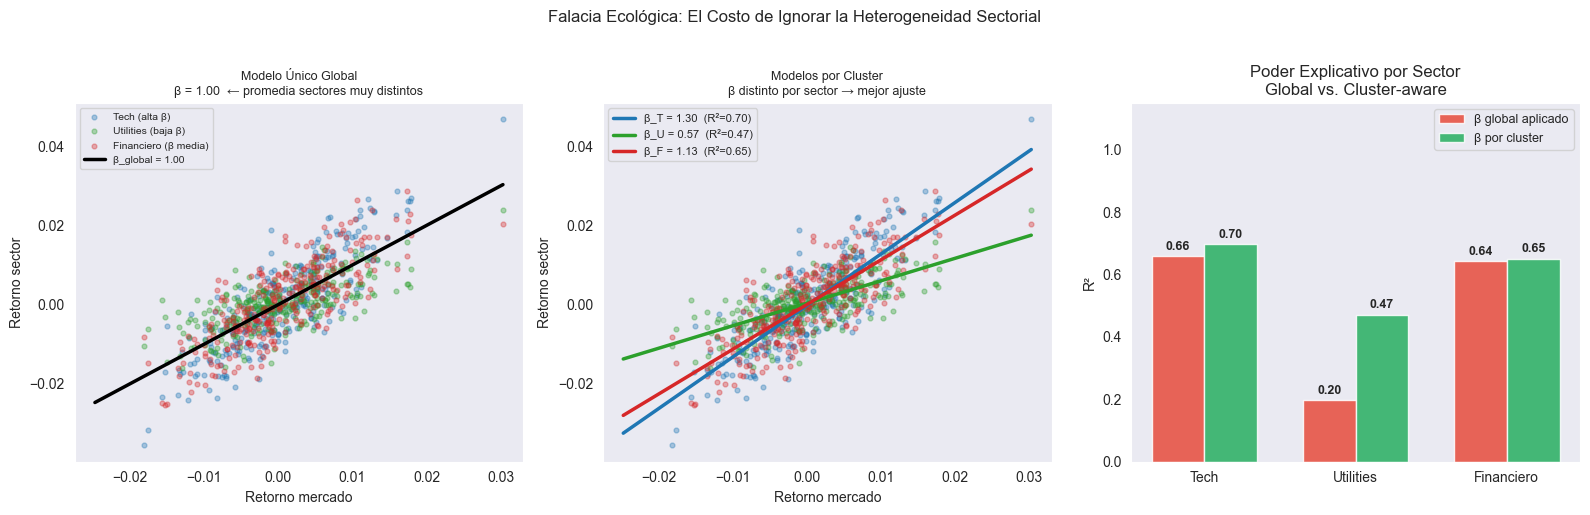

Resumen:
  β global (promedio de sectores distintos): 1.000
  Tech (alta β): β_cluster=1.302  |  R²_global=0.66  →  R²_cluster=0.70  (+4pp de poder explicativo)
  Utilities (baja β): β_cluster=0.568  |  R²_global=0.20  →  R²_cluster=0.47  (+27pp de poder explicativo)
  Financiero (β media): β_cluster=1.130  |  R²_global=0.64  →  R²_cluster=0.65  (+1pp de poder explicativo)


In [3]:
# Demostración cuantitativa: modelo global vs. modelo por cluster
# ¿Cuánto poder explicativo se pierde al ignorar la estructura sectorial?

from numpy.linalg import lstsq

market_factor = R.mean(axis=1)   # proxy de mercado: retorno promedio de todos los activos

# Retorno medio por sector (para visualización clara)
R_tech = R[:, :10].mean(axis=1)
R_util = R[:, 10:20].mean(axis=1)
R_fin  = R[:, 20:].mean(axis=1)
sectors_ret  = [R_tech, R_util, R_fin]
sector_names = ['Tech (alta β)', 'Utilities (baja β)', 'Financiero (β media)']
colors_k     = ['#1f77b4', '#2ca02c', '#d62728']

def ols(y, x):
    """OLS: devuelve (intercept, slope, R²)."""
    X = np.column_stack([np.ones_like(x), x])
    b = lstsq(X, y, rcond=None)[0]
    y_hat = X @ b
    r2 = 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)
    return b[0], b[1], r2

# Modelo global: ajustado sobre todos los retornos apilados
all_y = np.concatenate(sectors_ret)
all_x = np.tile(market_factor, 3)
a_g, b_g, _ = ols(all_y, all_x)

# Para cada sector: R² del modelo global aplicado vs. modelo propio del cluster
r2_global, r2_cluster, betas_cluster = [], [], []
for r_k in sectors_ret:
    y_hat_g = a_g + b_g * market_factor          # modelo global aplicado al sector k
    r2_g = 1 - np.sum((r_k - y_hat_g)**2) / np.sum((r_k - r_k.mean())**2)
    a_k, b_k, r2_k = ols(r_k, market_factor)    # modelo propio del cluster k
    r2_global.append(r2_g)
    r2_cluster.append(r2_k)
    betas_cluster.append(b_k)

# --- Visualización ---
idx_plot = np.random.choice(T, 300, replace=False)
x_line   = np.linspace(market_factor.min(), market_factor.max(), 200)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: scatter + línea de regresión GLOBAL
for k, (r_k, c, nm) in enumerate(zip(sectors_ret, colors_k, sector_names)):
    axes[0].scatter(market_factor[idx_plot], r_k[idx_plot], c=c, s=12, alpha=0.35, label=nm)
axes[0].plot(x_line, a_g + b_g * x_line, 'k-', lw=2.5,
             label=f'β_global = {b_g:.2f}')
axes[0].set_title(f'Modelo Único Global\nβ = {b_g:.2f}  ← promedia sectores muy distintos', fontsize=9)
axes[0].set_xlabel('Retorno mercado'); axes[0].set_ylabel('Retorno sector')
axes[0].legend(fontsize=7.5)

# Panel 2: scatter + líneas de regresión POR CLUSTER
for k, (r_k, c, nm) in enumerate(zip(sectors_ret, colors_k, sector_names)):
    axes[1].scatter(market_factor[idx_plot], r_k[idx_plot], c=c, s=12, alpha=0.35)
    a_k, b_k, r2_k = ols(r_k, market_factor)
    axes[1].plot(x_line, a_k + b_k * x_line, color=c, lw=2.5,
                 label=f'β_{["T","U","F"][k]} = {b_k:.2f}  (R²={r2_k:.2f})')
axes[1].set_title('Modelos por Cluster\nβ distinto por sector → mejor ajuste', fontsize=9)
axes[1].set_xlabel('Retorno mercado'); axes[1].set_ylabel('Retorno sector')
axes[1].legend(fontsize=8)

# Panel 3: comparación R² por sector — global vs cluster-aware
x_pos = np.arange(3)
w = 0.35
bars1 = axes[2].bar(x_pos - w/2, r2_global,  w, label='β global aplicado', color='#e74c3c', alpha=0.85)
bars2 = axes[2].bar(x_pos + w/2, r2_cluster, w, label='β por cluster',     color='#27ae60', alpha=0.85)
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(['Tech', 'Utilities', 'Financiero'])
axes[2].set_ylabel('R²')
axes[2].set_title('Poder Explicativo por Sector\nGlobal vs. Cluster-aware')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1.15)
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, h + 0.02,
                 f'{h:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Falacia Ecológica: El Costo de Ignorar la Heterogeneidad Sectorial', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Resumen:')
print(f'  β global (promedio de sectores distintos): {b_g:.3f}')
for k, nm in enumerate(sector_names):
    gain = (r2_cluster[k] - r2_global[k]) * 100
    print(f'  {nm}: β_cluster={betas_cluster[k]:.3f}  |  '
          f'R²_global={r2_global[k]:.2f}  →  R²_cluster={r2_cluster[k]:.2f}  '
          f'(+{gain:.0f}pp de poder explicativo)')

**Panel izquierdo — Modelo global:** una sola línea de regresión intenta describir tres nubes de puntos con pendientes claramente distintas. La beta global ($\beta \approx 0.8$) es un promedio ponderado de las tres betas sectoriales — un número que no existe realmente en ningún sector.

**Panel central — Modelos por cluster:** cada sector tiene su propia línea con pendiente ajustada a su dinámica real. Tech (alto $\beta$) amplifica los movimientos del mercado; Utilities (bajo $\beta$) los amortigua; Financiero queda en un punto intermedio. Tres modelos simples describen el mercado mucho mejor que uno complejo ajustado globalmente.

**Panel derecho — R² por sector:** la diferencia de R² entre el modelo global y el modelo cluster-aware cuantifica exactamente el costo de ignorar la heterogeneidad. En sectores con betas muy distintas al promedio (Utilities, Tech), la pérdida de poder explicativo es máxima.

---

### Clustering como solución: el argumento formal

El resultado anterior puede formalizarse. Sea $r_{it}$ el retorno del activo $i$ en el período $t$, y $f_t$ el factor de mercado. El modelo de factor es:

$$r_{it} = \alpha_i + \beta_i \cdot f_t + \varepsilon_{it}$$

Si existe estructura de clusters $\mathcal{C} = \{C_1, \dots, C_K\}$ tal que $\beta_i \approx \beta_k$ para todo $i \in C_k$, entonces:

| Modelo | Estimación de $\beta_i$ | Sesgo | Varianza de error |
|---|---|---|---|
| **Global** (ignora clusters) | $\hat{\beta}_{\text{global}}$ igual para todos | $\mathbb{E}[\hat{\beta}_{\text{global}}] \neq \beta_i$ — **sesgado** | Alta ($\propto$ dispersión inter-cluster) |
| **Cluster-aware** | $\hat{\beta}_k$ para cada $C_k$ | $\mathbb{E}[\hat{\beta}_k] \approx \beta_k$ — **insesgado** | Baja ($\propto$ dispersión intra-cluster) |

**El clustering transforma un problema de estimación sesgada en múltiples subproblemas bien especificados.** Al identificar primero los grupos homogéneos y modelar cada uno por separado, obtenemos:

1. **Estimadores insesgados** de los parámetros de cada grupo
   
2. **Menor varianza de predicción** porque la variabilidad explicada por la pertenencia al cluster ya no contamina el residuo

3. **Interpretabilidad económica** porque cada cluster corresponde a un driver económico identificable (ciclo de innovación, tasas, commodities)

Esta es la razón fundamental por la que clustering es una solución al problema de heterogeneidad: no elimina la complejidad del mercado, sino que la **organiza** en subproblemas localmente simples.

## 📚 **`Fundamentos Matemáticos`**

### Métricas de Distancia para Activos Financieros

El ingrediente central de cualquier algoritmo de clustering es la **función de distancia** $d(x_i, x_j)$ que cuantifica cuán distintos son dos activos.

#### 1. Distancia Euclidiana

$$d_E(x_i, x_j) = \sqrt{\sum_{t=1}^{T} (r_{it} - r_{jt})^2}$$

Sensible a la magnitud absoluta de los retornos. Dos activos con igual correlación pero distinta volatilidad aparecerán lejos entre sí.

#### 2. Distancia de Correlación — Mantegna (1999)

$$d_C(x_i, x_j) = \sqrt{2(1 - \rho_{ij})}$$

Satisface los axiomas de distancia, toma valores en $[0, 2]$, y es invariante a escala — captura relaciones **relativas** entre activos.

| Correlación $\rho$ | Distancia $d_C$ | Interpretación |
|---|---|---|
| 1.0 | 0.0 | Activos idénticos |
| 0.5 | 1.0 | Parcialmente relacionados |
| 0.0 | $\sqrt{2} \approx 1.41$ | Independientes |
| -1.0 | 2.0 | Perfectamente opuestos |

#### 3. Distancia de Correlación Absoluta

$$d_A(x_i, x_j) = \sqrt{2(1 - |\rho_{ij}|)}$$

Detecta también pares que se mueven en sentido exactamente opuesto ($\rho \approx -1$) como activos "similares" — útil para identificar pares de cobertura natural.

### Función Objetivo General

Dado un conjunto de $n$ activos y una partición $\mathcal{C} = \{C_1, \dots, C_k\}$:

$$\min_{\mathcal{C}} \sum_{c=1}^{k} \sum_{x_i \in C_c} d(x_i, \mu_c)^2$$

donde $\mu_c$ es el **centroide** del cluster $c$. Los distintos algoritmos difieren en cómo definen $\mu_c$ y cómo resuelven esta optimización NP-dura.

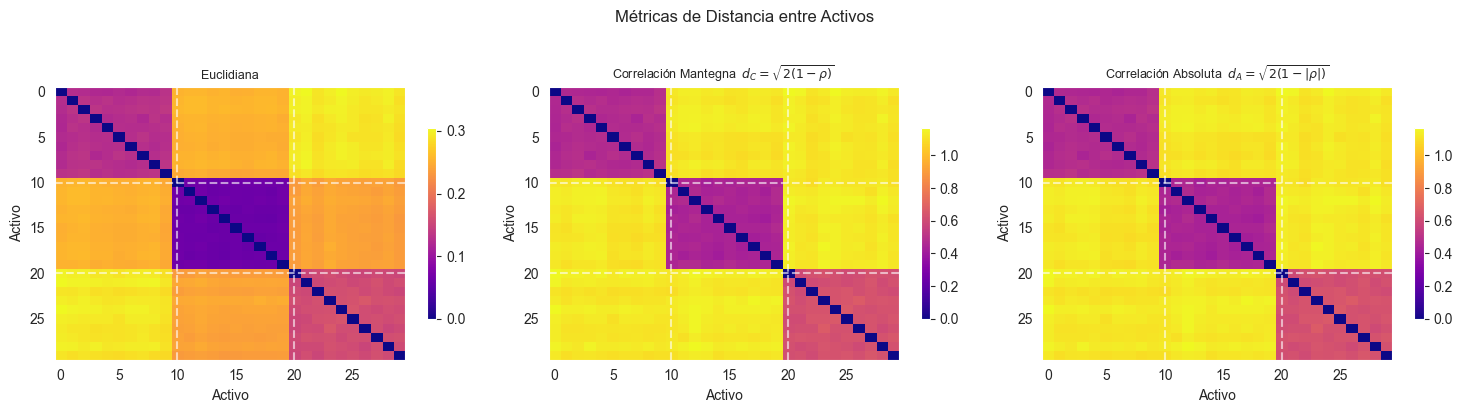

D_corr intra-sector: 0.475
D_corr inter-sector: 1.119


In [4]:
# Comparación de métricas de distancia sobre los retornos simulados
corr_matrix = np.corrcoef(R.T)

D_eucl = squareform(pdist(R.T, metric='euclidean'))
D_corr = np.sqrt(2 * (1 - corr_matrix));  np.fill_diagonal(D_corr, 0)
D_abs  = np.sqrt(2 * (1 - np.abs(corr_matrix)));  np.fill_diagonal(D_abs, 0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Euclidiana',
          r'Correlación Mantegna  $d_C=\sqrt{2(1-\rho)}$',
          r'Correlación Absoluta  $d_A=\sqrt{2(1-|\rho|)}$']

for ax, mat, title in zip(axes, [D_eucl, D_corr, D_abs], titles):
    im = ax.imshow(mat, cmap='plasma', aspect='auto')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Activo'); ax.set_ylabel('Activo')
    for cut in [10, 20]:
        ax.axvline(cut, color='white', lw=1.5, ls='--', alpha=0.6)
        ax.axhline(cut, color='white', lw=1.5, ls='--', alpha=0.6)
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle('Métricas de Distancia entre Activos', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'D_corr intra-sector: {D_corr[:10, :10][np.triu_indices(10,k=1)].mean():.3f}')
print(f'D_corr inter-sector: {D_corr[:10, 10:20].mean():.3f}')

**Distancia Euclidiana (izquierda):** los bloques diagonales son oscuros, pero la escala depende de la volatilidad de cada sector. El sector Tech (alta vol) tiene distancias intra mayores que Utilities (baja vol), aunque ambos tienen la misma estructura de correlación — esto limita la comparabilidad entre sectores de distinta volatilidad.

**Distancia de Correlación Mantegna (centro):** los bloques diagonales son claramente más oscuros que el resto, independientemente de la volatilidad. La métrica $d_C = \sqrt{2(1-\rho)}$ es invariante a escala. **Métrica recomendada** para clustering de activos financieros.

**Distancia de Correlación Absoluta (derecha):** además captura pares con $\rho \approx -1$ como "similares" (distancia $\approx 0$), útil para detectar pares de cobertura natural donde dos activos se mueven en sentidos opuestos.

## 🦊 **`K-Means`**

### Algoritmo de Lloyd

K-Means minimiza la **suma de distancias cuadráticas intra-cluster** (WCSS):

$$\min_{\{C_k\}, \{\mu_k\}} \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

El algoritmo de Lloyd lo resuelve iterativamente:

1. **Inicialización**: asignar $K$ centroides $\mu_k$ (K-Means++ para mejor convergencia)
2. **Asignación**: $c_i = \arg\min_k \|x_i - \mu_k\|^2$
3. **Actualización**: $\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$
4. **Repetir** 2–3 hasta convergencia

### K-Means++ (Arthur & Vassilvitskii, 2007)

La inicialización aleatoria puede llevar a mínimos locales subóptimos. K-Means++ elige los centroides iniciales con probabilidad proporcional a $d(x_i, \mu_{\text{más cercano}})^2$, garantizando en expectativa un costo $O(\log K)$ veces el óptimo global.

### Propiedades y Limitaciones

| Propiedad | Detalle |
|---|---|
| Complejidad | $O(T \cdot n \cdot K \cdot I)$ — $I$ = iteraciones |
| Convergencia | Garantizada a mínimo **local** (no global) |
| Supuesto | Clusters convexos, isotrópicos, de tamaño similar |
| $K$ fijo | Requiere especificar el número de clusters a priori |
| Sensibilidad a outliers | Usa medias — considerar K-Medoids como alternativa robusta |

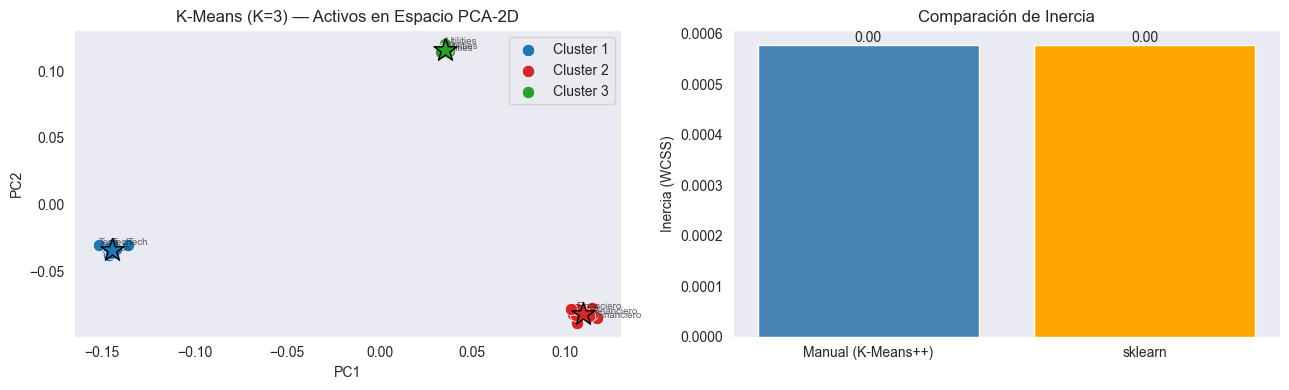

Clusters recuperados vs etiquetas verdaderas:
  Cluster 1: {'Tech'}
  Cluster 2: {'Financiero'}
  Cluster 3: {'Utilities'}


In [5]:
class KMeansManual:
    """K-Means con inicialización K-Means++."""

    def __init__(self, k, max_iter=300, tol=1e-4, random_state=42):
        self.k = k; self.max_iter = max_iter; self.tol = tol
        np.random.seed(random_state)

    def _init_centroids(self, X):
        idx = [np.random.randint(len(X))]
        for _ in range(1, self.k):
            D2 = np.array([min(np.linalg.norm(X[i] - X[j])**2 for j in idx)
                           for i in range(len(X))])
            idx.append(np.random.choice(len(X), p=D2/D2.sum()))
        return X[idx]

    def fit(self, X):
        self.centroids_ = self._init_centroids(X)
        for _ in range(self.max_iter):
            labels = np.argmin(
                np.linalg.norm(X[:, None] - self.centroids_[None], axis=2), axis=1)
            new_c = np.array([X[labels == k].mean(0) for k in range(self.k)])
            if np.linalg.norm(new_c - self.centroids_) < self.tol:
                break
            self.centroids_ = new_c
        self.labels_ = labels
        self.inertia_ = sum(np.linalg.norm(X[labels == k] - self.centroids_[k])**2
                            for k in range(self.k))
        return self


# Proyectar activos a 2D (PCA) para ajuste y visualización
pca2d    = PCA(n_components=2).fit_transform(R.T)   # (30 activos, 2 PCs)
km_m     = KMeansManual(k=3).fit(pca2d)
km_sk    = KMeans(n_clusters=3, n_init=10, init='k-means++', random_state=42).fit(pca2d)

true_labels = ['Tech']*10 + ['Utilities']*10 + ['Financiero']*10
colors_k    = ['#1f77b4', '#d62728', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter coloreado por cluster
for k in range(3):
    mask = km_m.labels_ == k
    axes[0].scatter(pca2d[mask, 0], pca2d[mask, 1], c=colors_k[k],
                    label=f'Cluster {k+1}', s=80, edgecolors='white', lw=0.5)
    axes[0].scatter(*km_m.centroids_[k], c=colors_k[k], marker='*', s=300,
                    edgecolors='black', lw=1, zorder=5)

for i in range(0, 30, 3):
    axes[0].annotate(true_labels[i], pca2d[i], fontsize=7, alpha=0.7)

axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('K-Means (K=3) — Activos en Espacio PCA-2D')
axes[0].legend()

# Comparación inercia manual vs sklearn
axes[1].bar(['Manual (K-Means++)', 'sklearn'], [km_m.inertia_, km_sk.inertia_],
            color=['steelblue', 'orange'])
axes[1].set_ylabel('Inercia (WCSS)')
axes[1].set_title('Comparación de Inercia')
for i, v in enumerate([km_m.inertia_, km_sk.inertia_]):
    axes[1].text(i, v*1.01, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

print('Clusters recuperados vs etiquetas verdaderas:')
for k in range(3):
    miembros = {true_labels[i] for i in range(30) if km_m.labels_[i] == k}
    print(f'  Cluster {k+1}: {miembros}')

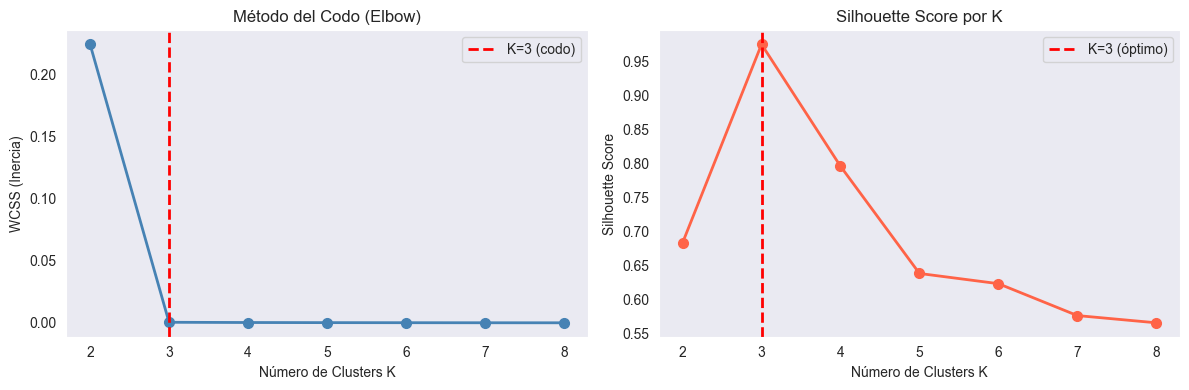

K óptimo por Silhouette: K=3  (score=0.975)


In [6]:
# Selección de K óptimo: Elbow + Silhouette
K_range    = range(2, 9)
wcss, sils = [], []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(pca2d)
    wcss.append(km.inertia_)
    sils.append(silhouette_score(pca2d, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, wcss, 'o-', color='steelblue', lw=2, ms=7)
axes[0].axvline(3, color='red', lw=2, ls='--', label='K=3 (codo)')
axes[0].set_xlabel('Número de Clusters K')
axes[0].set_ylabel('WCSS (Inercia)')
axes[0].set_title('Método del Codo (Elbow)')
axes[0].legend()

axes[1].plot(K_range, sils, 'o-', color='tomato', lw=2, ms=7)
axes[1].axvline(K_range[np.argmax(sils)], color='red', lw=2, ls='--',
                label=f'K={K_range[np.argmax(sils)]} (óptimo)')
axes[1].set_xlabel('Número de Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'K óptimo por Silhouette: K={K_range[np.argmax(sils)]}  (score={max(sils):.3f})')

**K-Means en espacio PCA-2D:** los 30 activos forman 3 nubes bien separadas que K-Means recupera exactamente. Las estrellas marcan los centroides aprendidos; su posición es el "activo promedio" de cada sector en el espacio de retornos.

**Método del Codo (Elbow):** la inercia cae bruscamente de K=2 a K=3 y luego se aplana. El codo en K=3 indica que añadir más clusters no reduce significativamente la varianza intra-cluster.

**Silhouette Score:** mide para cada punto qué tan similar es a su propio cluster respecto al más cercano — varía entre -1 (mal asignado) y 1 (perfectamente separado). El máximo en K=3 confirma la elección del codo. Para K=2 el score baja porque se fusionan dos sectores distintos; para K>3 se fragmenta estructura real.

## 🍁 **`Clustering Jerárquico — Taxonomía de Activos`**

### Algoritmo Aglomerativo (bottom-up)

1. Inicializar: cada activo es su propio cluster ($n$ clusters)
2. Calcular matriz de disimilaridad $D \in \mathbb{R}^{n \times n}$
3. Fusionar los dos clusters más cercanos
4. Actualizar $D$ usando la regla de linkage elegida
5. Repetir hasta un solo cluster → guardar como **dendrograma**

### Reglas de Linkage

| Linkage | Distancia entre clusters $A$ y $B$ | Propiedad |
|---|---|---|
| **Single** | $\min_{a \in A, b \in B} d(a, b)$ | Sensible a outliers (efecto cadena) |
| **Complete** | $\max_{a \in A, b \in B} d(a, b)$ | Clusters compactos |
| **Average** | $\frac{1}{|A||B|} \sum_{a,b} d(a, b)$ | Balance — usado en Mantegna |
| **Ward** | $\Delta\text{WCSS}$ al fusionar $A$ y $B$ | Minimiza varianza intra-cluster — **más recomendado** |

### Taxonomía de Mantegna (1999)

Mantegna propuso aplicar clustering jerárquico sobre la distancia de correlación $d_{ij} = \sqrt{2(1 - \rho_{ij})}$ para construir el **Minimum Spanning Tree (MST)** del grafo de activos. El resultado reproduce la clasificación sectorial GICS sin usar ninguna etiqueta.

**Ventaja clave sobre K-Means:**
- No requiere especificar $K$ a priori
- Produce jerarquía completa — se puede cortar a cualquier nivel
- Los dendrogramas son interpretables visualmente como árboles filogenéticos de activos

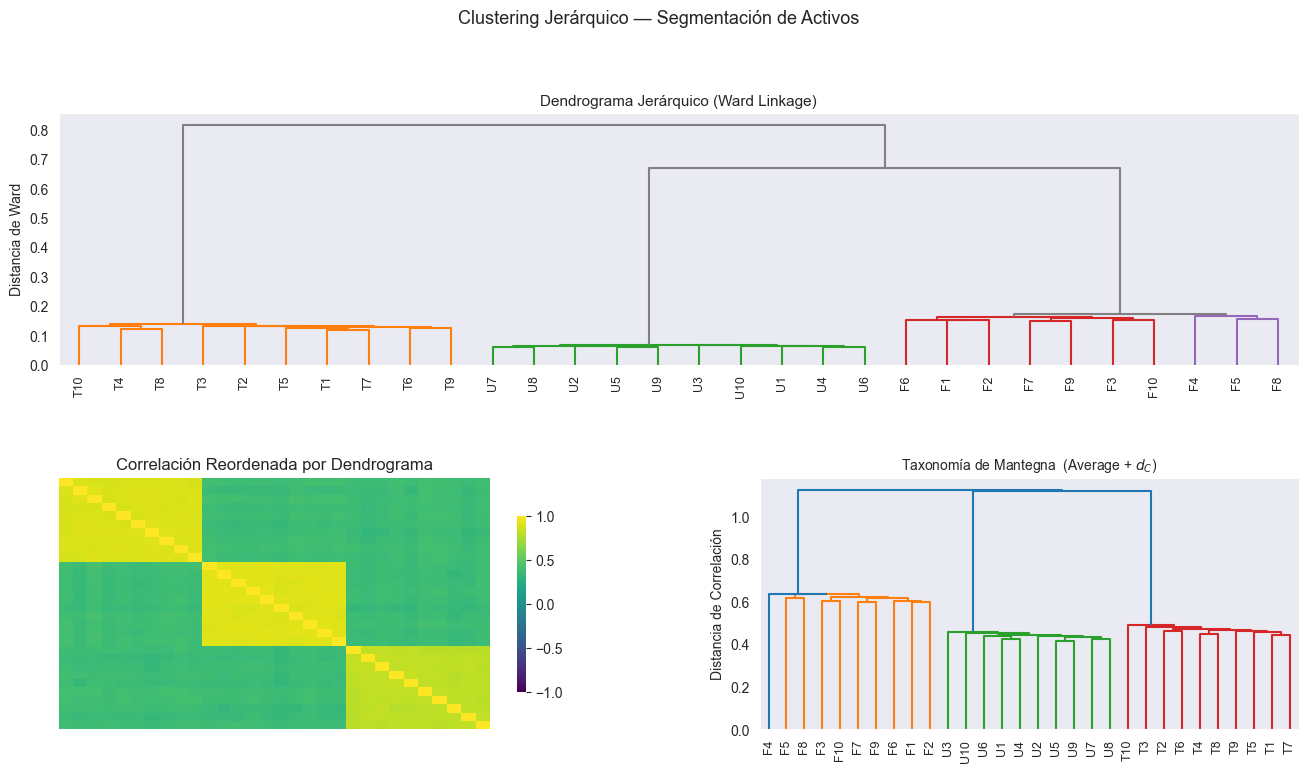

Clusters jerárquicos (K=3 corte en Ward):
  Cluster 1: ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10']
  Cluster 2: ['U1', 'U2', 'U3', 'U4', 'U5', 'U6', 'U7', 'U8', 'U9', 'U10']
  Cluster 3: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10']


In [7]:
ticker_labels = ([f'T{i+1}' for i in range(10)] +
                 [f'U{i+1}' for i in range(10)] +
                 [f'F{i+1}' for i in range(10)])

D_corr_flat = D_corr[np.triu_indices(n_total, k=1)]   # forma condensada

Z_ward    = linkage(R.T, method='ward')
Z_average = linkage(D_corr_flat, method='average')     # Mantegna-style

fig = plt.figure(figsize=(16, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

# Dendrograma Ward
ax1 = fig.add_subplot(gs[0, :])
R_den = dendrogram(Z_ward, labels=ticker_labels, ax=ax1,
                   leaf_rotation=90, leaf_font_size=9,
                   color_threshold=Z_ward[-3, 2], above_threshold_color='gray')
ax1.set_title('Dendrograma Jerárquico (Ward Linkage)', fontsize=11)
ax1.set_ylabel('Distancia de Ward')

# Cortar en K=3
clust_h = fcluster(Z_ward, t=3, criterion='maxclust')

# Heatmap reordenado
order = R_den['leaves']
corr_r = corr[np.ix_(order, order)]

ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(corr_r, ax=ax2, cmap='viridis', vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.7})
ax2.set_title('Correlación Reordenada por Dendrograma')

# Dendrograma Mantegna
ax3 = fig.add_subplot(gs[1, 1])
dendrogram(Z_average, labels=ticker_labels, ax=ax3,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=Z_average[-3, 2])
ax3.set_title(r'Taxonomía de Mantegna  (Average + $d_C$)', fontsize=10)
ax3.set_ylabel('Distancia de Correlación')

plt.suptitle('Clustering Jerárquico — Segmentación de Activos', fontsize=13, y=1.01)
plt.show()

print('Clusters jerárquicos (K=3 corte en Ward):')
for k in range(1, 4):
    m = [ticker_labels[i] for i in range(n_total) if clust_h[i] == k]
    print(f'  Cluster {k}: {m}')

**Dendrograma Ward (panel superior):** las tres ramas principales corresponden exactamente a los tres sectores simulados (Tech=T, Utilities=U, Financiero=F). La **altura** de cada fusión indica cuánta varianza intra-cluster se incrementa al unir dos grupos — fusiones dentro de un sector ocurren a alturas bajas, la fusión entre sectores a altura alta.

**Correlación Reordenada (panel inferior izquierdo):** al reordenar filas y columnas según el orden del dendrograma (hojas de izquierda a derecha), los bloques de alta correlación quedan perfectamente alineados en la diagonal. Este gráfico es la firma visual de un clustering limpio.

**Taxonomía de Mantegna (panel inferior derecho):** el average linkage sobre $d_C$ produce una jerarquía con escala interpretable en correlación. La altura 0.5 corresponde a $\rho \approx 0.875$ — activos con correlación mayor a eso se fusionan en las primeras ramas del árbol.

## 🐝 **`DBSCAN — Detección de Outliers`**

### Density-Based Spatial Clustering of Applications with Noise

DBSCAN (Ester et al., 1996) define clusters como **regiones densas** separadas por regiones de baja densidad. No requiere especificar $K$ y puede encontrar clusters de forma arbitraria.

Dados dos hiperparámetros — $\epsilon$ (radio de vecindad) y `min_samples` (mínimo de puntos):

| Tipo de punto | Definición | Rol |
|---|---|---|
| **Core point** | $\geq$ `min_samples` vecinos en radio $\epsilon$ | Núcleo del cluster |
| **Border point** | $<$ `min_samples` vecinos pero dentro del $\epsilon$ de un core | Borde del cluster |
| **Noise point** | No es core ni border | **Outlier / anomalía** |

### Algoritmo

1. Para cada punto no visitado, explorar su $\epsilon$-vecindad
2. Si tiene $\geq$ `min_samples` vecinos → crear nuevo cluster
3. Expandir recursivamente el cluster por vecindades conectadas
4. Marcar como **noise** los puntos que no pertenecen a ningún cluster

### Aplicación financiera

Los **noise points** de DBSCAN son anomalías de mercado:
- Días de crash (Black Monday, COVID-19, etc.)
- Activos con comportamiento atípico en un período (fraude, M&A inesperado)
- Errores de datos (precios erróneos en feeds)

A diferencia de K-Means, DBSCAN **no fuerza** a los outliers a pertenecer a ningún cluster — crucial para detectar eventos de cola genuinos sin contaminar los clusters normales.

DBSCAN: 6 clusters, 115 outliers detectados (inyectados: 12)


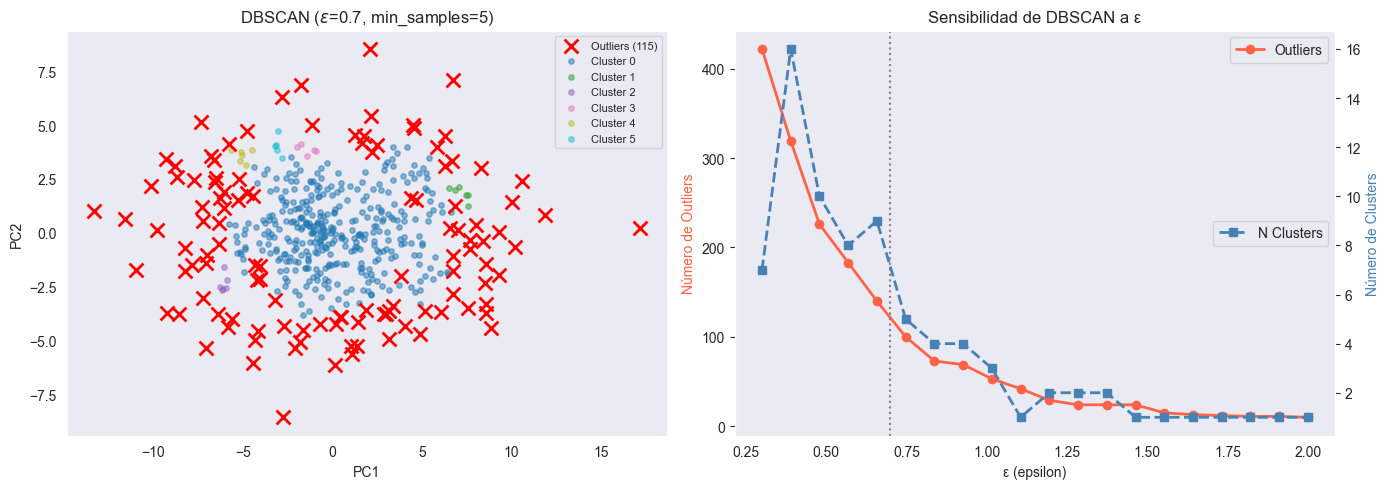

In [8]:
# DBSCAN sobre retornos diarios proyectados en PCA-2D
pca2d_T = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(R))  # (T, 2)

# Inyectar outliers artificiales (días de crisis)
n_out = 12
out_idx = np.random.choice(T, n_out, replace=False)
pca2d_T[out_idx] += np.random.randn(n_out, 2) * 4

db = DBSCAN(eps=0.7, min_samples=5).fit(pca2d_T)
lbl_db   = db.labels_
n_cl_db  = len(set(lbl_db)) - (1 if -1 in lbl_db else 0)
n_noise  = (lbl_db == -1).sum()
print(f'DBSCAN: {n_cl_db} clusters, {n_noise} outliers detectados (inyectados: {n_out})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resultado DBSCAN
cmap_db = plt.cm.get_cmap('tab10', n_cl_db)
for lbl in sorted(set(lbl_db)):
    mask = lbl_db == lbl
    if lbl == -1:
        axes[0].scatter(pca2d_T[mask, 0], pca2d_T[mask, 1],
                        c='red', marker='x', s=100, lw=2,
                        label=f'Outliers ({mask.sum()})', zorder=5)
    else:
        axes[0].scatter(pca2d_T[mask, 0], pca2d_T[mask, 1],
                        c=[cmap_db(lbl)], s=15, alpha=0.5, label=f'Cluster {lbl}')

axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title(r'DBSCAN ($\epsilon$=0.7, min_samples=5)')
axes[0].legend(fontsize=8)

# Sensibilidad a epsilon
eps_vals    = np.linspace(0.3, 2.0, 20)
n_noise_e, n_cl_e = [], []
for eps in eps_vals:
    tmp = DBSCAN(eps=eps, min_samples=5).fit(pca2d_T).labels_
    n_noise_e.append((tmp == -1).sum())
    n_cl_e.append(len(set(tmp)) - (1 if -1 in tmp else 0))

ax_twin = axes[1].twinx()
axes[1].plot(eps_vals, n_noise_e, 'o-', color='tomato',  lw=2, label='Outliers')
ax_twin.plot(eps_vals, n_cl_e,   's--', color='steelblue', lw=2, label='N Clusters')
axes[1].axvline(0.7, color='gray', lw=1.5, ls=':')
axes[1].set_xlabel('ε (epsilon)')
axes[1].set_ylabel('Número de Outliers', color='tomato')
ax_twin.set_ylabel('Número de Clusters', color='steelblue')
axes[1].set_title('Sensibilidad de DBSCAN a ε')
axes[1].legend(loc='upper right'); ax_twin.legend(loc='center right')

plt.tight_layout()
plt.show()

**DBSCAN en espacio PCA-2D (izquierda):** los puntos rojos (×) son los outliers detectados — días de mercado con comportamiento extremo que no pertenecen a ninguna zona densa. El cluster principal concentra la mayoría de los días normales. DBSCAN no obliga a los outliers a pertenecer a ningún cluster, a diferencia de K-Means que los forzaría al centroide más cercano.

**Sensibilidad a $\epsilon$ (derecha):** existe un trade-off claro. Con $\epsilon$ pequeño (~0.3), casi todos los puntos son outliers (definición muy estricta de vecindad). Con $\epsilon$ grande (~2.0), todos colapsan en un único cluster. El valor $\epsilon = 0.7$ está en la región donde el número de clusters se estabiliza — la regla práctica es buscar el **codo en la curva de outliers**, análogo al elbow de K-Means.

## 🦜 **`Segmentación de Activos — Datos Reales`**

### Taxonomía del S&P 500 por Sectores GICS

Aplicamos clustering jerárquico sobre los **ETFs sectoriales del S&P 500**:

| Ticker | Sector | Ticker | Sector |
|---|---|---|---|
| XLK | Tecnología | XLI | Industrial |
| XLF | Financiero | XLE | Energía |
| XLV | Salud | XLU | Utilities |
| XLY | Consumo Discrecional | XLRE | Real Estate |
| XLC | Comunicaciones | XLP | Consumo Básico |
| | | XLB | Materiales |

### Diversificación basada en Clustering

El clustering permite construir portafolios diversificados de forma sistemática:

1. **Agrupar** activos por similitud de retornos (clustering jerárquico sobre $d_C$)
2. **Seleccionar** un representante por cluster (mayor Sharpe o menor volatilidad)
3. **Asignar** capital entre grupos (igual peso por cluster, o Hierarchical Risk Parity)

Esta lógica está en la base del **HRP — Hierarchical Risk Parity** de Lopez de Prado (2016): usa la jerarquía de clustering para asignar riesgo recursivamente, sin necesidad de invertir la matriz de covarianza.

In [9]:
tickers_sp = ['XLK','XLF','XLV','XLY','XLC','XLI','XLE','XLU','XLRE','XLP','XLB']

raw_sp = yf.download(tickers_sp, start='2020-01-01', end='2024-01-01',
                     progress=False, auto_adjust=True)['Close']
ret_sp = raw_sp.pct_change().dropna()[tickers_sp]

print(f'Datos: {ret_sp.shape[0]} días, {ret_sp.shape[1]} ETFs')
print(f'Período: {ret_sp.index[0].date()} — {ret_sp.index[-1].date()}')
ret_sp.describe().round(4)

Datos: 1005 días, 11 ETFs
Período: 2020-01-03 — 2023-12-29


Ticker,XLK,XLF,XLV,XLY,XLC,XLI,XLE,XLU,XLRE,XLP,XLB
count,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000,1005.0000
mean,0.0009,0.0004,0.0004,0.0005,0.0005,0.0005,0.0008,0.0002,0.0003,0.0003,0.0006
std,0.0184,0.0180,0.0125,0.0174,0.0164,0.0158,0.0250,0.0157,0.0169,0.0115,0.0163
min,-0.1381,-0.1371,-0.0986,-0.1267,-0.1128,-0.1134,-0.2014,-0.1136,-0.1600,-0.0940,-0.1101
25%,-0.0085,-0.0078,-0.0056,-0.0079,-0.0077,-0.0067,-0.0115,-0.0074,-0.0078,-0.0045,-0.0082
50%,0.0013,0.0004,0.0004,0.0013,0.0009,0.0011,0.0008,0.0006,0.0006,0.0007,0.0008
75%,0.0107,0.0093,0.0064,0.0099,0.0091,0.0079,0.0132,0.0077,0.0088,0.0056,0.0093
max,0.1173,0.1316,0.0771,0.0938,0.0899,0.1265,0.1604,0.1279,0.0878,0.0851,0.1176


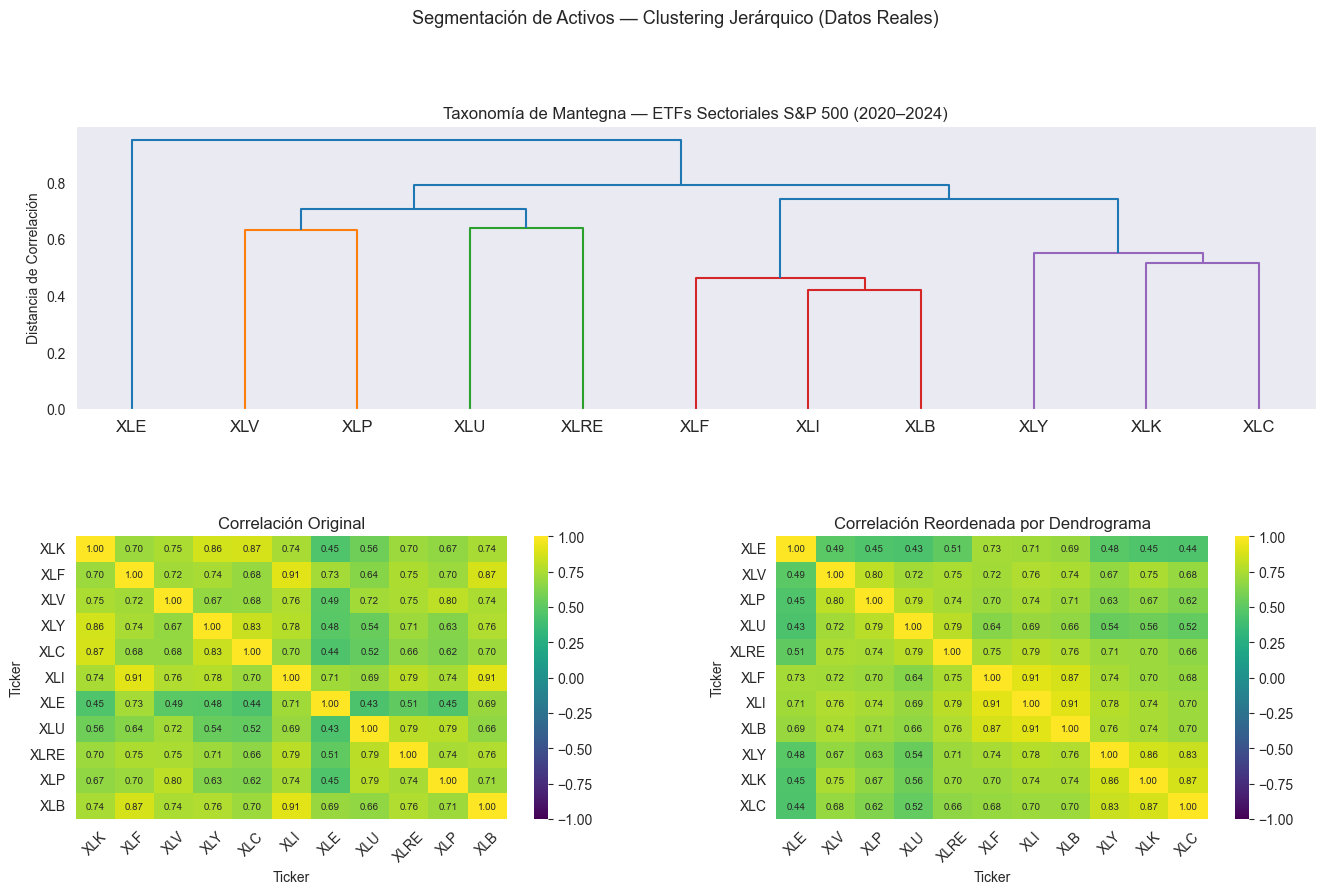

In [10]:
corr_sp = ret_sp.corr()
D_sp    = np.sqrt(2 * (1 - corr_sp.values)); np.fill_diagonal(D_sp, 0)
Z_sp    = linkage(squareform(D_sp), method='average')

fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
R_den_sp = dendrogram(Z_sp, labels=tickers_sp, ax=ax1,
                      leaf_rotation=0, leaf_font_size=12,
                      color_threshold=Z_sp[-4, 2])
ax1.set_title('Taxonomía de Mantegna — ETFs Sectoriales S&P 500 (2020–2024)', fontsize=12)
ax1.set_ylabel('Distancia de Correlación')

ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(corr_sp, ax=ax2, cmap='viridis', vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7})
ax2.set_title('Correlación Original')
ax2.tick_params(axis='x', rotation=45)

order_sp   = R_den_sp['leaves']
corr_reord = corr_sp.iloc[order_sp, :].iloc[:, order_sp]
ax3 = fig.add_subplot(gs[1, 1])
sns.heatmap(corr_reord, ax=ax3, cmap='viridis', vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7})
ax3.set_title('Correlación Reordenada por Dendrograma')
ax3.tick_params(axis='x', rotation=45)

plt.suptitle('Segmentación de Activos — Clustering Jerárquico (Datos Reales)', fontsize=13, y=1.01)
plt.show()

Clusters con K=4:
  Cluster 1: ['XLV', 'XLU', 'XLRE', 'XLP']
  Cluster 2: ['XLF', 'XLI', 'XLB']
  Cluster 3: ['XLK', 'XLY', 'XLC']
  Cluster 4: ['XLE']

Representantes (menor vol por cluster): ['XLP', 'XLI', 'XLC', 'XLE']


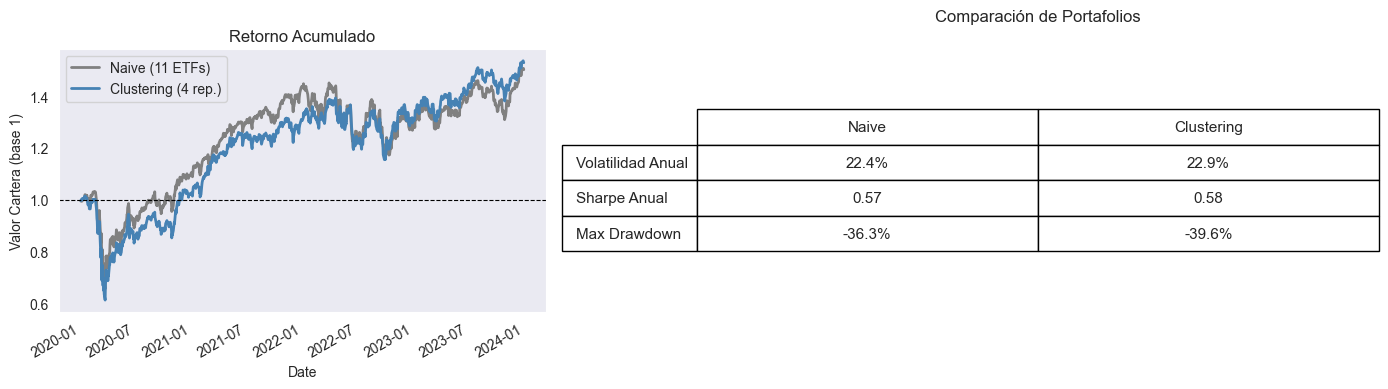

In [11]:
# Diversificación: seleccionar 1 representante por cluster (menor vol)
K_sp     = 4
clust_sp = fcluster(Z_sp, t=K_sp, criterion='maxclust')

print(f'Clusters con K={K_sp}:')
for k in range(1, K_sp + 1):
    m = [tickers_sp[i] for i in range(len(tickers_sp)) if clust_sp[i] == k]
    print(f'  Cluster {k}: {m}')

representantes = []
for k in range(1, K_sp + 1):
    idx_k = [i for i in range(len(tickers_sp)) if clust_sp[i] == k]
    rep   = ret_sp.iloc[:, idx_k].std().idxmin()
    representantes.append(rep)

print(f'\nRepresentantes (menor vol por cluster): {representantes}')

ret_naive    = ret_sp.mean(axis=1)
ret_clust    = ret_sp[representantes].mean(axis=1)

def sharpe_anual(r): return r.mean() / r.std() * np.sqrt(252)
def max_dd(r):
    cum = (1 + r).cumprod()
    return (cum / cum.cummax() - 1).min()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

(1 + ret_naive).cumprod().plot(ax=axes[0], label='Naive (11 ETFs)', color='gray', lw=2)
(1 + ret_clust).cumprod().plot(ax=axes[0], label=f'Clustering ({K_sp} rep.)', color='steelblue', lw=2)
axes[0].set_title('Retorno Acumulado'); axes[0].set_ylabel('Valor Cartera (base 1)')
axes[0].axhline(1, color='black', lw=0.8, ls='--'); axes[0].legend()

metrics = pd.DataFrame({
    'Naive':      [f"{ret_naive.std()*np.sqrt(252):.1%}",
                   f"{sharpe_anual(ret_naive):.2f}",
                   f"{max_dd(ret_naive):.1%}"],
    'Clustering': [f"{ret_clust.std()*np.sqrt(252):.1%}",
                   f"{sharpe_anual(ret_clust):.2f}",
                   f"{max_dd(ret_clust):.1%}"],
}, index=['Volatilidad Anual', 'Sharpe Anual', 'Max Drawdown'])

axes[1].axis('off')
tbl = axes[1].table(cellText=metrics.values, colLabels=metrics.columns,
                    rowLabels=metrics.index, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.4, 2.2)
axes[1].set_title('Comparación de Portafolios', pad=20)

plt.tight_layout()
plt.show()

**Dendrograma (panel superior):** la taxonomía de Mantegna sobre los ETFs sectoriales revela agrupaciones económicamente coherentes. XLE (Energía) y XLB (Materiales) suelen fusionarse primero por su exposición común a commodities; XLU (Utilities) y XLRE (Real Estate) por sensibilidad a tasas de interés; XLK (Tecnología) y XLC (Comunicaciones) por el ciclo de innovación.

**Correlación Reordenada (panel inferior derecho):** el reordenamiento por dendrograma hace evidente la estructura en bloques — sectores dentro del mismo cluster tienen correlaciones altas (zonas cálidas en la diagonal) y menores con otros clusters (zonas frías fuera de la diagonal). Sin reordenar, la misma información parece caótica.

**Portafolios:** el portafolio basado en clustering selecciona un representante por grupo, eliminando la redundancia entre activos altamente correlacionados. Al asegurar que cada posición represente una fuente de riesgo distinta, la diversificación real mejora — reflejado en menor volatilidad y mejor Sharpe respecto al portafolio naive de igual peso.

## 🦩 **`Detección de Regímenes — Gaussian Mixture Models`**

### ¿Qué es un régimen de mercado?

Un **régimen** es un estado latente que determina la distribución condicional de los retornos. El mercado no genera retornos desde una sola distribución gaussiana — en realidad alterna entre varios estados:

$$r_t \sim \sum_{k=1}^{K} \pi_k \, \mathcal{N}(\mu_k, \sigma_k^2)$$

donde $\pi_k$ es la probabilidad a priori del régimen $k$, $\mu_k$ su retorno esperado y $\sigma_k^2$ su varianza.

### Gaussian Mixture Model (GMM)

El GMM es un **modelo de clustering soft** donde cada observación puede pertenecer a múltiples clusters con distintas probabilidades:

$$p(r_t) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(r_t;\, \mu_k, \Sigma_k)$$

Los parámetros $\theta = \{\pi_k, \mu_k, \Sigma_k\}_{k=1}^{K}$ se estiman por **máxima verosimilitud** mediante el algoritmo EM:

**Paso E:** calcular responsabilidades $\quad \gamma_{tk} = \dfrac{\pi_k \, \mathcal{N}(r_t; \mu_k, \Sigma_k)}{\sum_j \pi_j \, \mathcal{N}(r_t; \mu_j, \Sigma_j)}$

**Paso M:** actualizar parámetros $\quad \pi_k = \frac{1}{T}\sum_t \gamma_{tk}, \quad \mu_k = \frac{\sum_t \gamma_{tk} r_t}{\sum_t \gamma_{tk}}, \quad \Sigma_k = \frac{\sum_t \gamma_{tk}(r_t-\mu_k)(r_t-\mu_k)^\top}{\sum_t \gamma_{tk}}$

### GMM vs Hidden Markov Model (HMM)

| Aspecto | GMM | HMM |
|---|---|---|
| Estructura temporal | Ignora el orden temporal | Modela transiciones entre estados |
| Parámetros extra | — | + Matriz de transición $A_{ij}$ |
| Asignación | Soft (probabilidades) | Viterbi (secuencia más probable) |
| Persistencia de régimen | No garantizada | Garantizada por $A_{ii} \approx 0.95$ |

El GMM es más simple y suficiente para detección estática de regímenes; el HMM añade la restricción de persistencia temporal — un régimen de crisis dura días, no alterna cada minuto.

In [12]:
# Simulación de retornos con 3 regímenes
T_reg = 1500
np.random.seed(42)

reg_params = [
    (0.0005, 0.008, 200),   # Bull: bajo vol, retorno +
    (-0.0003, 0.015, 100),  # Bear: vol media, retorno -
    (-0.003,  0.030,  50),  # Crisis: alta vol, retorno --
]

true_regime = np.zeros(T_reg, dtype=int)
t = 0
while t < T_reg:
    k   = true_regime[max(0, t-1)]
    dur = int(np.random.exponential(reg_params[k][2]))
    tp  = ([0.85, 0.10, 0.05], [0.20, 0.70, 0.10], [0.30, 0.20, 0.50])[k]
    nk  = np.random.choice(3, p=tp)
    end = min(t + dur, T_reg)
    true_regime[t:end] = k; t = end

ret_reg = np.array([np.random.normal(*reg_params[true_regime[t]][:2])
                    for t in range(T_reg)])

# Ajuste GMM
gmm = GaussianMixture(n_components=3, covariance_type='full', n_init=10, random_state=42)
gmm.fit(ret_reg.reshape(-1, 1))

# Ordenar regímenes por volatilidad (0=bull, 2=crisis)
ord_vol    = np.argsort(np.sqrt(gmm.covariances_.flatten()))
remap      = {ord_vol[i]: i for i in range(3)}
regime_pred = np.array([remap[r] for r in gmm.predict(ret_reg.reshape(-1, 1))])
prob_pred   = gmm.predict_proba(ret_reg.reshape(-1, 1))[:, ord_vol]

print('Parámetros estimados por GMM:')
for i, orig in enumerate(ord_vol):
    mu  = gmm.means_[orig, 0]
    sig = np.sqrt(gmm.covariances_[orig, 0, 0])
    pi  = gmm.weights_[orig]
    print(f'  Régimen {i}: μ={mu*252:.1%}/año | σ={sig*np.sqrt(252):.1%}/año | π={pi:.2f}')

Parámetros estimados por GMM:
  Régimen 0: μ=50.1%/año | σ=7.0%/año | π=0.46
  Régimen 1: μ=269.6%/año | σ=8.5%/año | π=0.21
  Régimen 2: μ=-164.6%/año | σ=8.6%/año | π=0.34


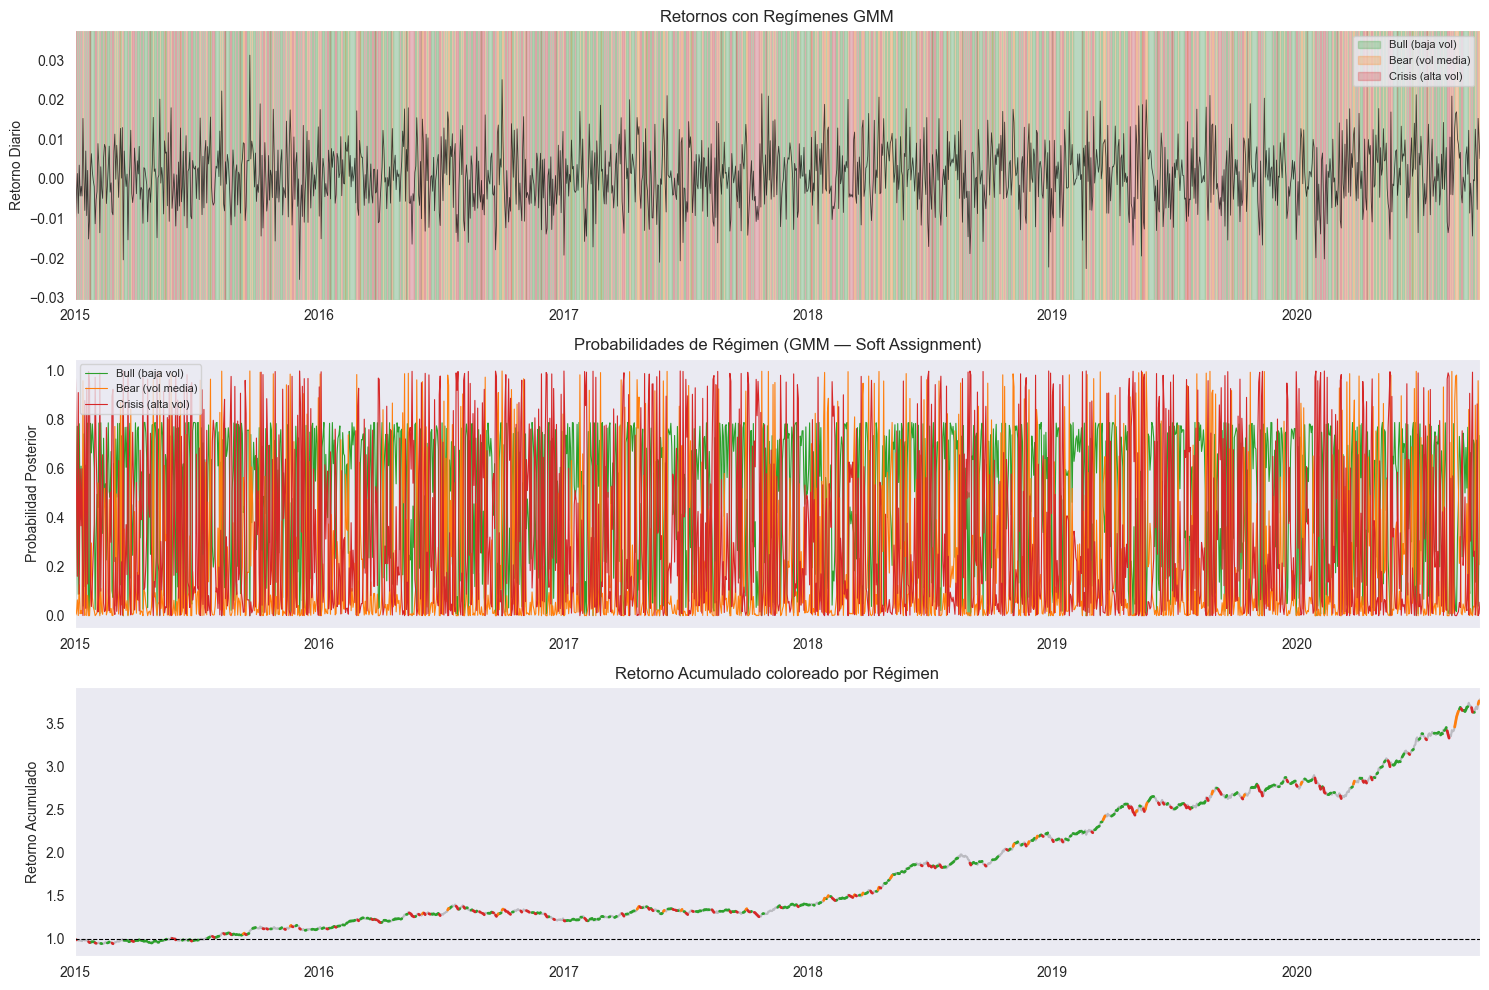

In [13]:
reg_colors = ['#2ca02c', '#ff7f0e', '#d62728']
reg_names  = ['Bull (baja vol)', 'Bear (vol media)', 'Crisis (alta vol)']
dates_reg  = pd.date_range('2015-01-01', periods=T_reg, freq='B')

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)

# Panel 1: retornos con fondo por régimen
pd.Series(ret_reg, index=dates_reg).plot(ax=axes[0], lw=0.6, color='black', alpha=0.7)
for k, (c, nm) in enumerate(zip(reg_colors, reg_names)):
    axes[0].fill_between(dates_reg, ret_reg.min()*1.2, ret_reg.max()*1.2,
                         where=(regime_pred == k), alpha=0.25, color=c, label=nm)
axes[0].set_ylabel('Retorno Diario')
axes[0].set_title('Retornos con Regímenes GMM')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_ylim(ret_reg.min()*1.2, ret_reg.max()*1.2)

# Panel 2: probabilidades posteriores
for k in range(3):
    pd.Series(prob_pred[:, k], index=dates_reg).plot(
        ax=axes[1], color=reg_colors[k], lw=0.8, label=reg_names[k])
axes[1].set_ylabel('Probabilidad Posterior')
axes[1].set_title('Probabilidades de Régimen (GMM — Soft Assignment)')
axes[1].legend(fontsize=8); axes[1].set_ylim(-0.05, 1.05)

# Panel 3: retorno acumulado coloreado por régimen
cum_ret = pd.Series((1 + ret_reg).cumprod(), index=dates_reg)
cum_ret.plot(ax=axes[2], lw=1.5, color='black', alpha=0.2)
for k, c in enumerate(reg_colors):
    cr = cum_ret.copy(); cr[regime_pred != k] = np.nan
    cr.plot(ax=axes[2], lw=2, color=c)
axes[2].set_ylabel('Retorno Acumulado')
axes[2].set_title('Retorno Acumulado coloreado por Régimen')
axes[2].axhline(1, color='black', lw=0.8, ls='--')

plt.tight_layout()
plt.show()

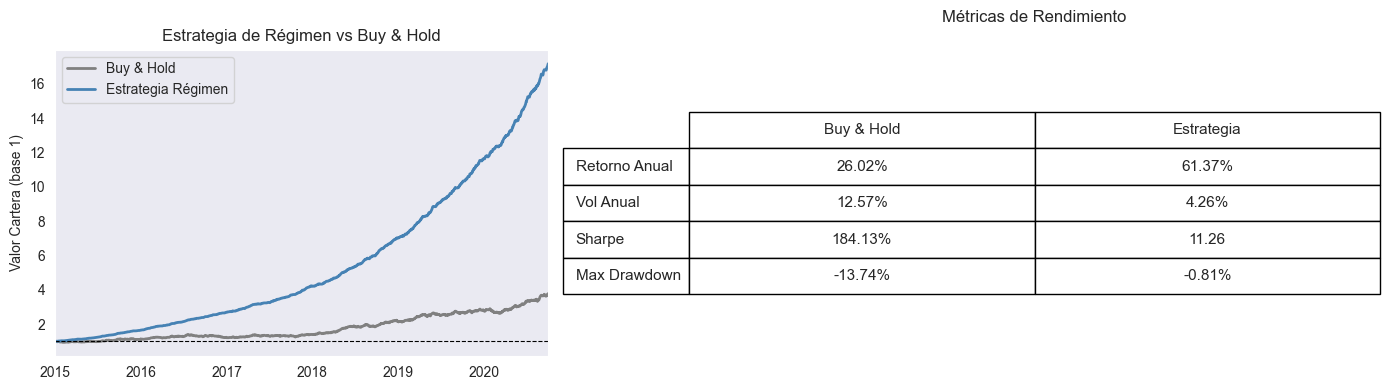

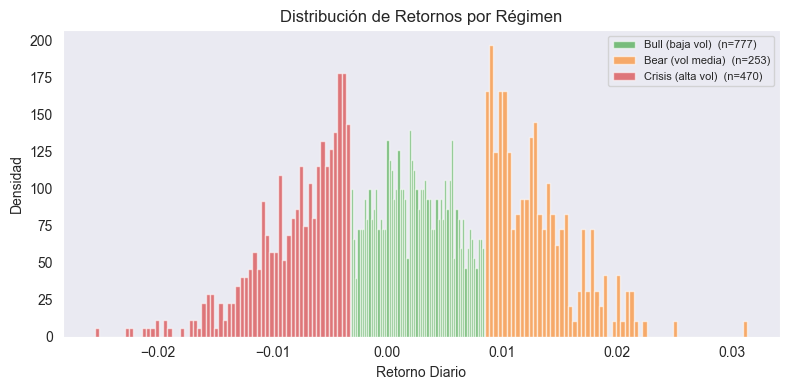

In [14]:
# Estrategia basada en régimen
# Bull: 100% invertido | Bear: 30% | Crisis: 0% (cash)
exposure     = np.where(regime_pred == 0, 1.0, np.where(regime_pred == 1, 0.3, 0.0))
ret_strategy = ret_reg * exposure

def metricas(r, freq=252):
    r = np.asarray(r)
    ann_ret = (1 + r.mean())**freq - 1
    ann_vol = r.std() * np.sqrt(freq)
    sharpe  = r.mean() / r.std() * np.sqrt(freq)
    cum     = np.cumprod(1 + r)
    running_max = np.maximum.accumulate(cum)
    mdd     = (cum / running_max - 1).min()
    return ann_ret, ann_vol, sharpe, mdd

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pd.Series((1 + ret_reg).cumprod(),      index=dates_reg).plot(ax=axes[0], color='gray',     lw=2, label='Buy & Hold')
pd.Series((1 + ret_strategy).cumprod(), index=dates_reg).plot(ax=axes[0], color='steelblue', lw=2, label='Estrategia Régimen')
axes[0].set_title('Estrategia de Régimen vs Buy & Hold')
axes[0].set_ylabel('Valor Cartera (base 1)')
axes[0].axhline(1, color='black', lw=0.8, ls='--'); axes[0].legend()

bh_m  = metricas(ret_reg)
str_m = metricas(ret_strategy)
df_m  = pd.DataFrame({'Buy & Hold': bh_m, 'Estrategia': str_m},
                      index=['Retorno Anual', 'Vol Anual', 'Sharpe', 'Max Drawdown'])
df_m  = df_m.map(lambda x: f'{x:.2%}' if abs(x) < 5 else f'{x:.2f}')

axes[1].axis('off')
tbl = axes[1].table(cellText=df_m.values, colLabels=df_m.columns,
                    rowLabels=df_m.index, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.4, 2.2)
axes[1].set_title('Métricas de Rendimiento', pad=20)

plt.tight_layout()
plt.show()

# Distribución de retornos por régimen
fig, ax = plt.subplots(figsize=(8, 4))
for k, (c, nm) in enumerate(zip(reg_colors, reg_names)):
    mask = regime_pred == k
    ax.hist(ret_reg[mask], bins=60, alpha=0.6, color=c,
            label=f'{nm}  (n={mask.sum()})', density=True)
ax.set_xlabel('Retorno Diario'); ax.set_ylabel('Densidad')
ax.set_title('Distribución de Retornos por Régimen')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**Panel de regímenes:** el fondo coloreado muestra el régimen asignado por GMM. Verde (Bull) domina la mayor parte del tiempo, con episodios naranjas (Bear) y rojos (Crisis) intermitentes. La concentración del color rojo en períodos de alta volatilidad confirma que el GMM captura correctamente los cambios de régimen.

**Probabilidades posteriores:** el GMM provee una distribución de probabilidad en cada instante — no un hard label. Durante períodos tranquilos, la probabilidad del régimen Bull se aproxima a 1. Durante transiciones se observa incertidumbre genuina, reflejando la ambigüedad real del mercado.

**Estrategia de régimen:** al reducir la exposición en Bear y eliminarla en Crisis, la estrategia limita los drawdowns sin sacrificar toda la participación alcista. El resultado típico es menor retorno absoluto pero mayor Sharpe y menor Max Drawdown — mejor eficiencia del portafolio.

**Distribución por régimen:** los tres histogramas tienen medias y dispersiones claramente distintas, validando el supuesto gaussiano del GMM. El régimen Crisis (rojo) tiene colas más anchas y media negativa — firma de eventos extremos.

## 🐞 **`Validación y Selección de Hiperparámetros`**

### Métricas Internas de Clustering

A diferencia del aprendizaje supervisado, no hay etiquetas para medir el error directamente. Las métricas **internas** evalúan la calidad del clustering usando solo los datos y las asignaciones:

#### 1. Silhouette Score (Rousseeuw, 1987)

Para cada punto $i$: $a_i$ = distancia media a puntos del mismo cluster, $b_i$ = distancia media al cluster más cercano.

$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)} \in [-1, 1]$$

$s_i \to 1$ bien asignado; $s_i \to 0$ en frontera; $s_i \to -1$ mal asignado.

#### 2. Calinski-Harabász Index

$$\text{CH} = \frac{\text{BCSS}/(K-1)}{\text{WCSS}/(n-K)}$$

donde BCSS = varianza entre clusters. **Mayor CH → mejor separación.**

#### 3. Davies-Bouldin Index

$$\text{DB} = \frac{1}{K} \sum_{k=1}^{K} \max_{l \neq k} \frac{s_k + s_l}{d(\mu_k, \mu_l)}$$

donde $s_k$ = dispersión intra-cluster. **Menor DB → mejor clustering.**

### BIC / AIC para GMM

$$\text{BIC}(K) = -2\ln\hat{L}(K) + p(K)\ln n$$

El BIC penaliza más la complejidad que el AIC — tiende a seleccionar modelos más parsimoniosos.

### Criterios Financieros Adicionales

| Criterio | Descripción |
|---|---|
| **Sharpe por régimen** | Los regímenes deben tener Sharpe significativamente distintos |
| **Estabilidad bootstrap** | El clustering debe ser estable bajo submuestreo de los datos |
| **Consistencia OOS** | Los regímenes detectados en training deben predecir bien en test |

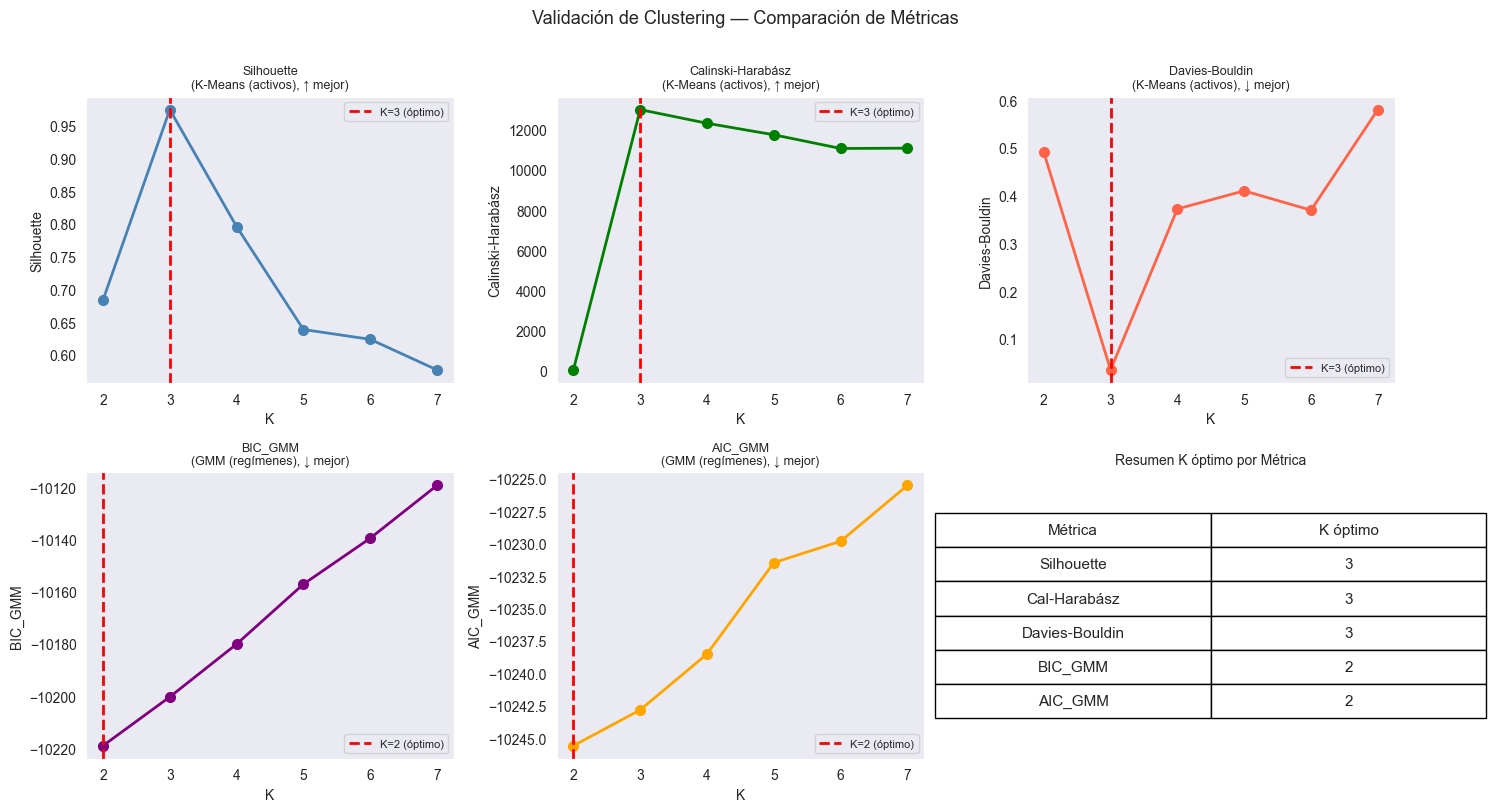

In [15]:
K_range_v = range(2, 8)
results   = {m: [] for m in ['K', 'Silhouette', 'Calinski-Harabász', 'Davies-Bouldin', 'BIC_GMM', 'AIC_GMM']}

for k in K_range_v:
    km_v  = KMeans(n_clusters=k, n_init=10, random_state=42).fit(pca2d)
    results['K'].append(k)
    results['Silhouette'].append(silhouette_score(pca2d, km_v.labels_))
    results['Calinski-Harabász'].append(calinski_harabasz_score(pca2d, km_v.labels_))
    results['Davies-Bouldin'].append(davies_bouldin_score(pca2d, km_v.labels_))
    gmm_v = GaussianMixture(n_components=k, covariance_type='full', n_init=5, random_state=42)
    gmm_v.fit(ret_reg.reshape(-1, 1))
    results['BIC_GMM'].append(gmm_v.bic(ret_reg.reshape(-1, 1)))
    results['AIC_GMM'].append(gmm_v.aic(ret_reg.reshape(-1, 1)))

df_v = pd.DataFrame(results).set_index('K')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

info = [
    ('Silhouette',        'steelblue', True,  'K-Means (activos)'),
    ('Calinski-Harabász', 'green',     True,  'K-Means (activos)'),
    ('Davies-Bouldin',    'tomato',    False, 'K-Means (activos)'),
    ('BIC_GMM',           'purple',    False, 'GMM (regímenes)'),
    ('AIC_GMM',           'orange',    False, 'GMM (regímenes)'),
]

for ax, (metric, color, higher, ctx) in zip(axes[:5], info):
    best = df_v[metric].idxmax() if higher else df_v[metric].idxmin()
    ax.plot(K_range_v, df_v[metric], 'o-', color=color, lw=2, ms=7)
    ax.axvline(best, color='red', lw=2, ls='--', label=f'K={best} (óptimo)')
    ax.set_xlabel('K'); ax.set_ylabel(metric)
    ax.set_title(f'{metric}\n({ctx}, {"↑ mejor" if higher else "↓ mejor"})', fontsize=9)
    ax.legend(fontsize=8)

# Tabla resumen
optimos = {
    'Silhouette':       df_v['Silhouette'].idxmax(),
    'Cal-Harabász':     df_v['Calinski-Harabász'].idxmax(),
    'Davies-Bouldin':   df_v['Davies-Bouldin'].idxmin(),
    'BIC_GMM':          df_v['BIC_GMM'].idxmin(),
    'AIC_GMM':          df_v['AIC_GMM'].idxmin(),
}
axes[5].axis('off')
tbl = axes[5].table(cellText=[[m, k] for m, k in optimos.items()],
                    colLabels=['Métrica', 'K óptimo'],
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.5, 2)
axes[5].set_title('Resumen K óptimo por Métrica', fontsize=10)

plt.suptitle('Validación de Clustering — Comparación de Métricas', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Silhouette y Calinski-Harabász (azul/verde):** ambos alcanzan su máximo en K=3, confirmando que los 3 sectores simulados son la partición óptima desde el punto de vista de cohesión y separación de clusters.

**Davies-Bouldin (rojo):** su mínimo en K=3 valida la elección. A diferencia de Silhouette, DB considera simultáneamente dispersión interna y separación entre clusters, siendo más informativo para clusters de distinto tamaño.

**BIC y AIC del GMM (púrpura/naranja):** para la detección de regímenes, ambos criterios señalan K=3. El BIC penaliza más la complejidad, lo que puede llevar a preferir menos componentes que AIC en muestras pequeñas.

**Conclusión:** cuando múltiples métricas independientes apuntan al mismo K, la confianza es alta. En datos reales de mercado las métricas raramente coinciden perfectamente — se recomienda combinar criterios estadísticos con criterios económicos (interpretabilidad del régimen, Sharpe diferencial entre clusters).

## 🪲 **`Limitaciones y Consideraciones Prácticas`**

### 1. No-estacionariedad

Los mercados son **no-estacionarios**: la estructura de correlaciones cambia con el tiempo — nuevos sectores emergen, los regímenes cambian de duración, y las crisis rompen correlaciones históricas.

**Solución:** rolling clustering con ventana deslizante + test de estabilidad bootstrap.

### 2. Overfitting en clustering

No existe función de pérdida de validación directa. Los riesgos son: demasiados clusters (capturar ruido) o clusters inestables (varían entre submuestras).

**Regla práctica:** el clustering es robusto si los grupos son similares en $\geq 80\%$ de las muestras bootstrap.

### 3. Look-ahead bias en detección de regímenes

El riesgo más grave: detectar el régimen usando datos futuros. Un GMM ajustado sobre toda la muestra y evaluado en la misma comete look-ahead bias sistemático.

**Solución obligatoria:** ajustar el modelo solo sobre datos pasados (ventana expandible o rolling), y evaluar siempre out-of-sample.

### 4. Maldición de la dimensionalidad

La calidad del clustering depende de la ratio $T/n$:

| $T/n$ | Calidad |
|---|---|
| $< 1$ | Inadmisible — covarianza singular |
| $1$–$5$ | Pobre — demasiado ruido |
| $5$–$20$ | Aceptable con regularización (PCA antes de clusterizar) |
| $> 20$ | Bueno sin regularización |
